# Experiment: Schutzwirkung von Glaze, Nightshade und Mist

Modul Smart Graphics / Generative AI in Visual Computing, HS Emden/Leer.

Dieses Notebook implementiert das Experiment:

| Schritt | Inhalt |
|---|---|
| 0 | Setup und Konfiguration |
| 1 | Daten laden und vereinheitlichen (512×512) |
| 2 | Schutz: Glaze/Nightshade (extern) + Mist-Re-Implementierung |
| 3 | Robustheitstransformationen (JPEG, Skalierung, Rauschen) |
| 4 | Metriken: PSNR, SSIM, LPIPS, CLIP |
| 5 | Visuelle Qualität |
| 6 | Robustheit |
| 7 | LoRA-Fine-Tuning + Generierung |
| 8 | Export der Ergebnisse (CSV/LaTeX/PNG) |

**Umgebung:** Google Colab (GPU-Laufzeit, T4) für Codlab, lokaler Rechner mit NVIDIA-RTX 2070 für Glaze und Nightshade Desktopanwendung.

**Ordnerstruktur** (wird automatisch angelegt):
```
experiment/
  data/original/     # Ausgangsbilder (15 Stück)
  data/original_resized/     # auf 512x512 resized Originalbilder
  data/glaze/        # extern mit Glaze geschützte Versionen
  data/nightshade/   # extern mit Nightshade geschützte Versionen
  data/mist/         # wird hier erzeugt (Re-Implementierung)
  lora/              # LoRA-Gewichte je Trainingsvariante
  results/           # Metriken (CSV + LaTeX) und Bildraster
```

## 0 Setup

Installiert die benötigten Pakete. In Colab nach der Installation ggf. *Laufzeit → Sitzung neu starten*.

In [1]:
# Pakete installieren (einmalig pro Sitzung)
%pip install -q "diffusers>=0.27" transformers accelerate peft lpips scikit-image pandas matplotlib safetensors
%pip uninstall -y torchao

In [2]:
import io, os, json, math, random, shutil, subprocess
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

@dataclass
class CFG:
    # --- Pfade & Modell ---
    base_dir: str = "experiment"   # Colab mit Drive: "/content/drive/MyDrive/experiment"
    model_id: str = "stable-diffusion-v1-5/stable-diffusion-v1-5"  # Fallback: "CompVis/stable-diffusion-v1-4"
    image_size: int = 512
    # --- Mist-Re-Implementierung (PGD) ---
    eps: float = 8 / 255        # L_inf-Budget
    pgd_alpha: float = 1 / 255  # Schrittweite
    pgd_steps: int = 100        # Optimierungsschritte pro Bild
    w_semantic: float = 1.0     # Gewicht semantischer Verlust (AdvDM)
    w_textural: float = 100.0   # Gewicht Texturverlust
    use_semantic: bool = True   # bei wenig VRAM: False
    # --- LoRA-Fine-Tuning ---
    lora_rank: int = 4
    lora_steps: int = 600
    lora_lr: float = 1e-4
    instance_prompt: str = "a painting in sks style"
    # --- Generierung / Auswertung ---
    n_images_per_prompt: int = 4
    seed: int = 42

cfg = CFG()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(torch.cuda.get_device_name(0),
          f"| VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNUNG: Keine GPU gefunden. Mist-Attacke und LoRA-Training sind auf CPU unpraktikabel langsam.")

# Reproduzierbarkeit
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)

# Ordnerstruktur anlegen
BASE = Path(cfg.base_dir)
DIRS = {name: BASE / "data" / name for name in ["original", "glaze", "nightshade", "mist", "original_resized"]}
RESULTS = BASE / "results"
LORA = BASE / "lora"
for p in list(DIRS.values()) + [RESULTS, LORA]:
    p.mkdir(parents=True, exist_ok=True)
print("Ordnerstruktur unter:", BASE.resolve())

Device: cuda
Tesla T4 | VRAM: 15.6 GB
Ordnerstruktur unter: /content/experiment


## 1 Datensatz

Hochladen von 15 Gemälden von Vincent van Gogh in einem konsistenten Stil  in `experiment/data/original/`. Die Originalbilder werden auf 512×512 zugeschnitten und skaliert und als PNG gespeichert, damit alle Werkzeuge identisches Ausgangsmaterial erhalten.


> **Hinweis:** Die Bilddaten werden über eine WebDAV-Freigabe (z. B. Nextcloud) geladen. Für eine eigene Ausführung `SHARE_URL` in der nächsten Zelle auf eine eigene Freigabe mit den Ordnern `original/`, `glaze/`, `nightshade/` und `mist/` setzen.

In [ ]:
# rclone installieren
!curl -fsSL https://rclone.org/install.sh | sudo bash

# WebDAV-Freigabe konfigurieren (eigene URL eintragen)
SHARE_URL = "https://<dein-server>/public.php/dav/files/<share-token>"

!rclone config create nextcloud_share webdav \
    url="{SHARE_URL}" \
    vendor="other"


In [4]:
!rclone copy nextcloud_share:original/ /content/experiment/data/original/ \
    --progress \
    --transfers 8 \
    --checkers 16

15 Originalbilder geladen: Garden with Courting CouplesSquare Saint-Pierre, Irises, Pollard Willow, Portrait of Camille Roulin, Self-Portrait as a Painter ...


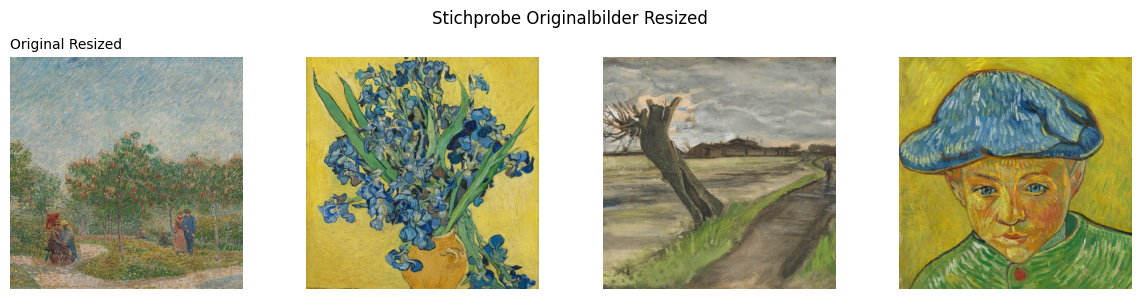

In [5]:
EXTS = {".png", ".jpg", ".jpeg", ".webp"}

def center_crop_resize(img: Image.Image, size: int) -> Image.Image:
    img = img.convert("RGB")
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    return img.resize((size, size), Image.LANCZOS)

def load_folder(folder: Path) -> dict:
    """Laedt alle Bilder eines Ordners als {stem: PIL.Image} (bereits 512x512 erwartet oder wird angepasst)."""
    out = {}
    for f in sorted(folder.iterdir()):
        if f.suffix.lower() in EXTS:
            out[f.stem] = center_crop_resize(Image.open(f), cfg.image_size)
    return out

# Originale vereinheitlichen und als PNG normieren
raw = load_folder(DIRS["original"])
assert len(raw) > 0, f"Keine Bilder in {DIRS['original']} gefunden. Bitte zuerst Bilder ablegen."
for stem, img in raw.items():
    img.save(DIRS["original_resized"] / f"{stem}.png")

# Alte Nicht-PNG-Duplikate entfernen (gleicher Stem)
# for f in DIRS["original"].iterdir():
#     if f.suffix.lower() in EXTS - {".png"} and (DIRS["original"] / f"{f.stem}.png").exists():
#         f.unlink()

original_resized = load_folder(DIRS["original_resized"])
originals = original_resized  # Alias: nachfolgende Zellen erwarten `originals`
print(f"{len(original_resized)} Originalbilder geladen:", ", ".join(list(original_resized)[:5]), "...")

def show_grid(rows: dict, title: str = "", save_to: Path | None = None, max_cols: int = 4):
    """rows: {Zeilenlabel: [PIL, ...]} – zeigt/speichert ein Bildraster."""
    n_rows = len(rows)
    if not rows or all(len(v) == 0 for v in rows.values()):
        print("show_grid: keine Bilder zum Anzeigen -> uebersprungen")
        return
    n_cols = max(1, min(max_cols, max((len(v) for v in rows.values()), default=0)))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), squeeze=False)
    for r, (label, imgs) in enumerate(rows.items()):
        for c in range(n_cols):
            ax = axes[r][c]
            ax.axis("off")
            if c < len(imgs):
                ax.imshow(imgs[c])
            if c == 0:
                ax.set_title(label, loc="left", fontsize=10)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=200, bbox_inches="tight")
        print("gespeichert:", save_to)
    plt.show()

show_grid({"Original Resized": list(original_resized.values())[:4]}, title="Stichprobe Originalbilder Resized")




## 2a Schutz mit Glaze und Nightshade (extern)

Glaze und Nightshade sind Closed-Source-Desktop-Anwendungen und laufen **außerhalb** dieses Notebooks:

1. **Glaze** (https://glaze.cs.uchicago.edu) auf alle Bilder aus `data/original/` anwenden.
2. **Nightshade** (https://nightshade.cs.uchicago.edu) analog anwenden.
3. Ergebnisse mit **identischen Dateinamen** (gleicher Stem wie das Original) in `data/glaze/` bzw. `data/nightshade/` ablegen.

Die Auswertung unten überspringt automatisch Werkzeuge, deren Ordner leer sind, sodass das Notebook auch ohne die externen Schritte lauffähig bleibt (dann nur Mist).

In [6]:
!rclone copy nextcloud_share:glaze/ /content/experiment/data/glaze/ \
    --progress \
    --transfers 8 \
    --checkers 16

!rclone copy nextcloud_share:nightshade/ /content/experiment/data/nightshade/ \
    --progress \
    --transfers 8 \
    --checkers 16

## 2b Mist-Re-Implementierung

Re-Implementierung des Mist-Verfahrens (AdvDM + Texturverlust) nach Liang et al. (2023):

- **Semantischer Verlust (AdvDM):** maximiert den Diffusionsverlust $\lVert \epsilon - \epsilon_\theta(z_t, t)\rVert^2$ (Monte-Carlo über zufällige $t$).
- **Texturverlust:** minimiert den Abstand der VAE-Latents zu einem kontrastreichen Zielmuster.
- **Optimierung:** PGD mit $L_\infty$-Budget `cfg.eps`, Schrittweite `cfg.pgd_alpha`, `cfg.pgd_steps` Schritte.

Laufzeit grob: ~1-3 min pro Bild auf einer T4 (mit semantischem Verlust).

In [7]:
!rclone copy nextcloud_share:mist/ /content/experiment/data/mist/ \
    --progress \
    --transfers 8 \
    --checkers 16

In [15]:
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

def load_sd_components(model_id: str):
    try:
        vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
    except Exception as e:
        print(f"Hinweis: {model_id} nicht ladbar ({e}). Fallback auf CompVis/stable-diffusion-v1-4.")
        model_id = "CompVis/stable-diffusion-v1-4"
        vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
    unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet") if cfg.use_semantic else None
    tok = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer") if cfg.use_semantic else None
    te = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder") if cfg.use_semantic else None
    sched = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler") if cfg.use_semantic else None
    return model_id, vae, unet, tok, te, sched

cfg.model_id, vae, unet, tokenizer, text_encoder, noise_scheduler = load_sd_components(cfg.model_id)

vae = vae.to(device).eval().requires_grad_(False)
if cfg.use_semantic:
    unet = unet.to(device).eval().requires_grad_(False)
    text_encoder = text_encoder.to(device).eval().requires_grad_(False)
    with torch.no_grad():
        tok_out = tokenizer([""], padding="max_length",
                            max_length=tokenizer.model_max_length, return_tensors="pt")
        EMPTY_PROMPT_EMB = text_encoder(tok_out.input_ids.to(device))[0]

SCALING = vae.config.scaling_factor  # 0.18215 bei SD 1.x

def pil_to_tensor01(img: Image.Image) -> torch.Tensor:
    x = torch.from_numpy(np.array(img)).float().permute(2, 0, 1) / 255.0
    return x.unsqueeze(0)

def tensor01_to_pil(x: torch.Tensor) -> Image.Image:
    x = x.squeeze(0).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return Image.fromarray((x * 255).round().astype(np.uint8))

def encode_latents(x01: torch.Tensor) -> torch.Tensor:
    """Bild [0,1] -> skalierte VAE-Latents (differenzierbar)."""
    return vae.encode(x01 * 2 - 1).latent_dist.mean * SCALING

def make_target_pattern(size: int, block: int = 16) -> Image.Image:
    """Kontrastreiches Schachbrett-Zielmuster fuer den Texturverlust."""
    yy, xx = np.mgrid[0:size, 0:size]
    pattern = (((yy // block) + (xx // block)) % 2).astype(np.float32)
    rgb = np.stack([pattern, 1 - pattern, pattern], axis=-1)
    return Image.fromarray((rgb * 255).astype(np.uint8))

target_img = make_target_pattern(cfg.image_size)
with torch.no_grad():
    TARGET_LATENTS = encode_latents(pil_to_tensor01(target_img).to(device))

def mist_attack(img: Image.Image) -> Image.Image:
    """PGD-Angriff mit fusioniertem Verlust: max( w_sem * L_diff - w_tex * L_tex )."""
    x0 = pil_to_tensor01(img).to(device)
    delta = torch.zeros_like(x0, requires_grad=True)

    for step in range(cfg.pgd_steps):
        x_adv = (x0 + delta).clamp(0, 1)
        z = encode_latents(x_adv)

        loss = -cfg.w_textural * F.mse_loss(z, TARGET_LATENTS)  # Texturverlust minimieren

        if cfg.use_semantic:  # Diffusionsverlust maximieren (Monte-Carlo ueber t)
            t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=device)
            noise = torch.randn_like(z)
            z_t = noise_scheduler.add_noise(z, noise, t)
            pred = unet(z_t, t, encoder_hidden_states=EMPTY_PROMPT_EMB).sample
            loss = loss + cfg.w_semantic * F.mse_loss(pred, noise)

        loss.backward()
        with torch.no_grad():
            delta += cfg.pgd_alpha * delta.grad.sign()          # Gradientenaufstieg
            delta.clamp_(-cfg.eps, cfg.eps)                     # Projektion aufs Budget
            delta.copy_((x0 + delta).clamp(0, 1) - x0)          # gueltiger Bildbereich
        delta.grad = None

    return tensor01_to_pil((x0 + delta).detach())

# Alle Originale schuetzen (bereits vorhandene Ergebnisse werden uebersprungen)
for stem, img in originals.items():
    out_path = DIRS["mist"] / f"{stem}.png"
    if out_path.exists():
        continue
    protected = mist_attack(img)
    protected.save(out_path)
    print("geschuetzt:", stem)

print("Mist-Re-Implementierung abgeschlossen.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

...

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

geschuetzt: Garden with Courting CouplesSquare Saint-Pierre
geschuetzt: Irises
geschuetzt: Pollard Willow


KeyboardInterrupt: 

### Copy Output to Nextcloud Server

In [ ]:
!rclone copy "/content/experiment/data/mist/" "nextcloud_share:mist/" \
    --progress \
    --transfers 4 \
    --checkers 8

## 3 Robustheitstransformationen

Praxisnahe Transformationen, wie sie beim Teilen im Web auftreten: JPEG-Kompression (q=75/50/25), Herunter-/Wiederhochskalieren (0,5×), Gauß-Rauschen (σ=0,02).

In [8]:
def t_identity(img: Image.Image) -> Image.Image:
    return img.copy()

def t_jpeg(img: Image.Image, quality: int) -> Image.Image:
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def t_rescale(img: Image.Image, factor: float = 0.5) -> Image.Image:
    w, h = img.size
    small = img.resize((int(w * factor), int(h * factor)), Image.LANCZOS)
    return small.resize((w, h), Image.LANCZOS)

def t_gauss_noise(img: Image.Image, sigma: float = 0.02) -> Image.Image:
    x = np.array(img).astype(np.float32) / 255.0
    x = np.clip(x + np.random.default_rng(cfg.seed).normal(0, sigma, x.shape), 0, 1)
    return Image.fromarray((x * 255).round().astype(np.uint8))

TRANSFORMS = {
    "ohne (Referenz)": t_identity,
    "JPEG q=75": lambda im: t_jpeg(im, 75),
    "JPEG q=50": lambda im: t_jpeg(im, 50),
    "JPEG q=25": lambda im: t_jpeg(im, 25),
    "Skalierung 0.5x": t_rescale,
    "Rauschen s=0.02": t_gauss_noise,
}
print("Transformationen:", list(TRANSFORMS))

Transformationen: ['ohne (Referenz)', 'JPEG q=75', 'JPEG q=50', 'JPEG q=25', 'Skalierung 0.5x', 'Rauschen s=0.02']


## 4 | Metriken

PSNR und SSIM (klassisch), LPIPS (perzeptuell, AlexNet-Variante) sowie CLIP-Bildähnlichkeit (Kosinus der Bildeinbettungen).

In [12]:
import numpy as np
import torch
from PIL import Image

def pil_to_tensor01(img: Image.Image) -> torch.Tensor:
    """Konvertiert ein PIL-RGB-Bild in einen Tensor [1, 3, H, W] im Bereich [0, 1]."""
    img = img.convert("RGB")

    array = np.asarray(img, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(array).permute(2, 0, 1)

    return tensor.unsqueeze(0)

In [13]:
import lpips
from skimage.metrics import structural_similarity, peak_signal_noise_ratio
from transformers import CLIPModel, CLIPProcessor

lpips_net = lpips.LPIPS(net="alex").to(device).eval()
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

@torch.no_grad()
def m_lpips(a: Image.Image, b: Image.Image) -> float:
    ta = pil_to_tensor01(a).to(device) * 2 - 1
    tb = pil_to_tensor01(b).to(device) * 2 - 1
    return float(lpips_net(ta, tb).item())

def m_psnr(a: Image.Image, b: Image.Image) -> float:
    return float(peak_signal_noise_ratio(np.array(a), np.array(b), data_range=255))

def m_ssim(a: Image.Image, b: Image.Image) -> float:
    return float(structural_similarity(np.array(a), np.array(b), channel_axis=2, data_range=255))

@torch.no_grad()
def clip_embed(imgs: list) -> torch.Tensor:
    inputs = clip_proc(images=imgs, return_tensors="pt").to(device)
    # Bypass get_image_features (Rueckgabetyp variiert je transformers-Version):
    # Vision-Tower + visual_projection direkt -> immer projizierte 512-dim Embeddings.
    vision = clip_model.vision_model(pixel_values=inputs["pixel_values"])
    emb = clip_model.visual_projection(vision.pooler_output)
    return F.normalize(emb, dim=-1)

def save_table(df: pd.DataFrame, name: str, float_format: str = "%.3f"):
    """Exportiert eine Ergebnistabelle als CSV und LaTeX nach results/."""
    df.to_csv(RESULTS / f"{name}.csv")
    (RESULTS / f"{name}.tex").write_text(df.to_latex(float_format=float_format), encoding="utf-8")
    print(f"exportiert: results/{name}.csv, results/{name}.tex")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

## 5 | Visuelle Qualität der geschützten Bilder

glaze: 15 Bilder
nightshade: 15 Bilder
mist: 15 Bilder


PSNR          SSIM         LPIPS       
              mean    std   mean    std   mean    std
Werkzeug                                             
glaze       40.765  0.095  0.977  0.007  0.020  0.012
mist        31.786  0.194  0.859  0.032  0.174  0.081
nightshade  36.239  0.268  0.941  0.018  0.075  0.030

exportiert: results/metrics_quality.csv, results/metrics_quality.tex
gespeichert: experiment/results/grid_quality.png


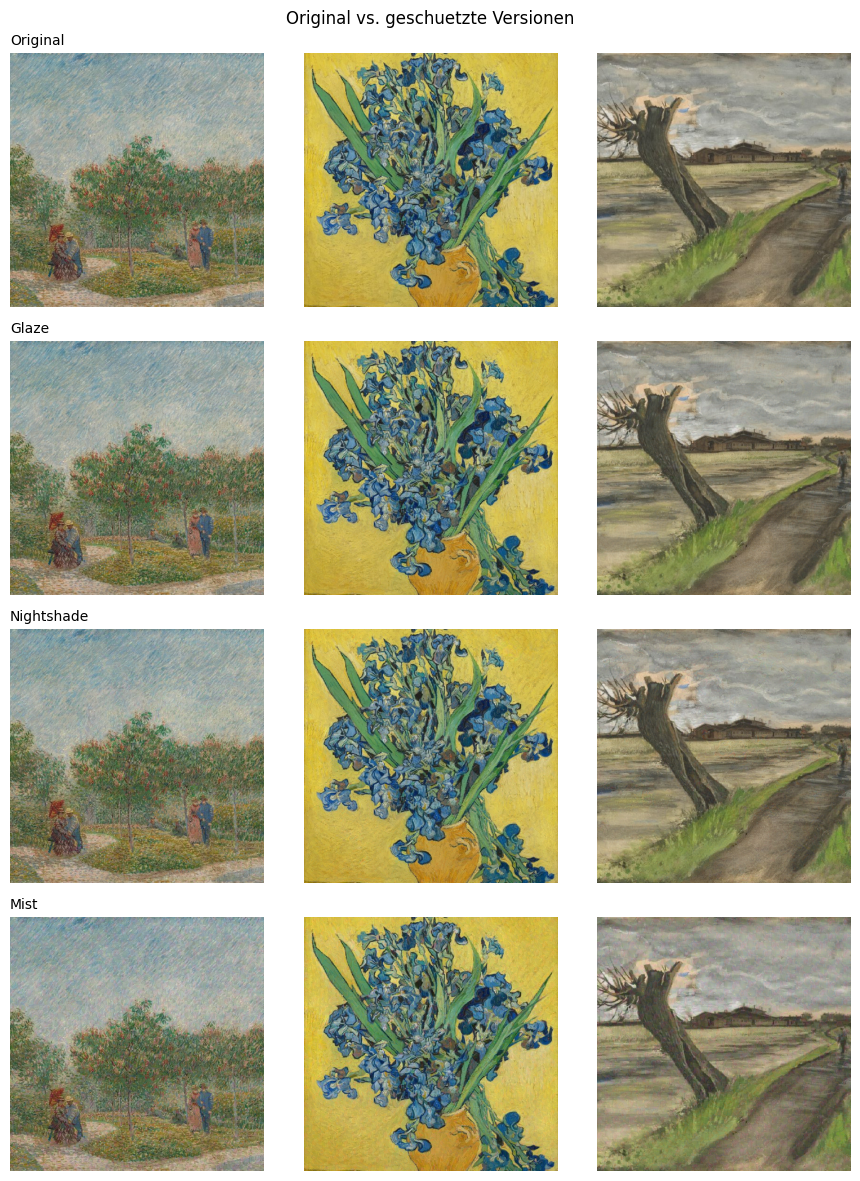

In [14]:
# Vorhandene Werkzeug-Ordner einsammeln (leere werden uebersprungen)
tool_sets = {}
for tool in ["glaze", "nightshade", "mist"]:
    imgs = load_folder(DIRS[tool])
    common = sorted(set(imgs) & set(originals))
    if common:
        tool_sets[tool] = {k: imgs[k] for k in common}
        print(f"{tool}: {len(common)} Bilder")
    else:
        print(f"{tool}: keine Bilder gefunden -> wird uebersprungen")

rows = []
for tool, imgs in tool_sets.items():
    for stem, prot in imgs.items():
        orig = originals[stem]
        rows.append({"Werkzeug": tool, "Bild": stem,
                     "PSNR": m_psnr(orig, prot),
                     "SSIM": m_ssim(orig, prot),
                     "LPIPS": m_lpips(orig, prot)})

df_quality = pd.DataFrame(rows)
summary_quality = df_quality.groupby("Werkzeug")[["PSNR", "SSIM", "LPIPS"]].agg(["mean", "std"]).round(3)
display(summary_quality)
save_table(summary_quality, "metrics_quality")
df_quality.to_csv(RESULTS / "metrics_quality_raw.csv", index=False)

# Bildraster (erste 3 Bilder: Original + je Werkzeug)
sample_stems = sorted(originals)[:3]
grid_rows = {"Original": [originals[s] for s in sample_stems]}
for tool, imgs in tool_sets.items():
    grid_rows[tool.capitalize()] = [imgs[s] for s in sample_stems if s in imgs]
show_grid(grid_rows, title="Original vs. geschuetzte Versionen",
          save_to=RESULTS / "grid_quality.png", max_cols=3)

## 6 | Robustheit gegenüber Transformationen

Indikator für den Verbleib der Perturbation: **LPIPS( T(Original), T(geschützt) )**. Sinkt der Wert nach einer Transformation deutlich unter die Referenz (ohne Transformation), wurde die Perturbation abgeschwächt.

In [15]:
rows = []
for tool, imgs in tool_sets.items():
    for t_name, t_fn in TRANSFORMS.items():
        vals = []
        for stem, prot in imgs.items():
            vals.append(m_lpips(t_fn(originals[stem]), t_fn(prot)))
        rows.append({"Werkzeug": tool, "Transformation": t_name,
                     "LPIPS_mean": float(np.mean(vals)), "LPIPS_std": float(np.std(vals))})

df_robust = pd.DataFrame(rows)
pivot_robust = df_robust.pivot(index="Transformation", columns="Werkzeug", values="LPIPS_mean")
pivot_robust = pivot_robust.reindex(list(TRANSFORMS)).round(3)
display(pivot_robust)
save_table(pivot_robust, "metrics_robustness")
df_robust.to_csv(RESULTS / "metrics_robustness_raw.csv", index=False)

Werkzeug,glaze,mist,nightshade
Transformation,,,
ohne (Referenz),0.020,0.174,0.075
JPEG q=75,0.034,0.175,0.101
JPEG q=50,0.041,0.147,0.093
JPEG q=25,0.044,0.130,0.089
Skalierung 0.5x,0.014,0.129,0.039
Rauschen s=0.02,0.015,0.147,0.059


exportiert: results/metrics_robustness.csv, results/metrics_robustness.tex


In [ ]:
!rclone copy "/content/experiment/results/" "nextcloud_share:results/" \
    --progress \
    --transfers 4 \
    --checkers 8

## 7 | Stilimitation per LoRA-Fine-Tuning

Für jede Variante (`original`, `glaze`, `nightshade`, `mist`) wird ein separates LoRA auf SD 1.5 trainiert (offizielles `diffusers`-Trainingsskript), anschließend werden mit **identischen Prompts und Seeds** Bilder generiert und mit den Originalwerken verglichen.

**Laufzeit:** ca. 20-40 min pro Variante auf einer T4. Bei Zeitmangel `cfg.lora_steps` reduzieren (z. B. 600).

### 7a | LoRA-Training je Variante

Trainiert pro Variante (`original`, `glaze`, `nightshade`, `mist`) ein separates DreamBooth-LoRA auf der SD-1.5-UNet (Attention-Layer, PEFT). Bereits vorhandene Gewichte werden uebersprungen. Ergebnis je Variante: `lora/<variante>/pytorch_lora_weights.safetensors`, kompatibel zu `pipe.load_lora_weights(...)` in Zelle 7b.

Laufzeit grob: 5-10 min pro Variante auf einer T4 (fp32, rank `cfg.lora_rank`, `cfg.lora_steps` Schritte).

In [ ]:
# 7a | LoRA-Fine-Tuning je Variante (DreamBooth-LoRA, PEFT)
import gc
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

from diffusers import (AutoencoderKL, UNet2DConditionModel, DDPMScheduler,
                       StableDiffusionPipeline)
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict

# Variante -> Bildordner. "original" trainiert auf den 512er-Originalen.
VARIANT_DIRS = {
    "original":   DIRS["original_resized"],
    "glaze":      DIRS["glaze"],
    "nightshade": DIRS["nightshade"],
    "mist":       DIRS["mist"],
}
# Nur Varianten mit tatsaechlich vorhandenen Bildern
VARIANTS = [v for v, d in VARIANT_DIRS.items()
            if d.exists() and any(f.suffix.lower() in EXTS for f in d.iterdir())]
print("Zu trainierende Varianten:", VARIANTS)


class InstanceDataset(Dataset):
    """DreamBooth-Instanzdaten: alle Bilder eines Ordners + fester Prompt."""
    def __init__(self, folder, tokenizer, prompt, size):
        self.paths = [f for f in sorted(folder.iterdir())
                      if f.suffix.lower() in EXTS]
        self.tf = T.Compose([
            T.Resize(size, interpolation=T.InterpolationMode.LANCZOS),
            T.CenterCrop(size),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]),   # -> [-1, 1]
        ])
        self.input_ids = tokenizer(
            prompt, padding="max_length", truncation=True,
            max_length=tokenizer.model_max_length, return_tensors="pt"
        ).input_ids[0]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return {"pixel_values": self.tf(img), "input_ids": self.input_ids}


def train_lora_for_variant(variant, folder):
    out_dir = LORA / variant
    out_dir.mkdir(parents=True, exist_ok=True)
    weights = out_dir / "pytorch_lora_weights.safetensors"
    if weights.exists():
        print(f"{variant}: LoRA existiert bereits -> uebersprungen")
        return

    # Komponenten frisch laden (fp32, robust auf T4)
    tokenizer    = CLIPTokenizer.from_pretrained(cfg.model_id, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(cfg.model_id, subfolder="text_encoder").to(device)
    vae          = AutoencoderKL.from_pretrained(cfg.model_id, subfolder="vae").to(device)
    unet         = UNet2DConditionModel.from_pretrained(cfg.model_id, subfolder="unet").to(device)
    sched        = DDPMScheduler.from_pretrained(cfg.model_id, subfolder="scheduler")

    vae.requires_grad_(False)
    text_encoder.requires_grad_(False)
    unet.requires_grad_(False)
    unet.enable_gradient_checkpointing()

    # LoRA nur auf die Attention-Projektionen der UNet
    lora_cfg = LoraConfig(
        r=cfg.lora_rank, lora_alpha=cfg.lora_rank,
        init_lora_weights="gaussian",
        target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    )
    unet.add_adapter(lora_cfg)
    lora_params = [p for p in unet.parameters() if p.requires_grad]

    ds = InstanceDataset(folder, tokenizer, cfg.instance_prompt, cfg.image_size)
    dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0)
    opt = torch.optim.AdamW(lora_params, lr=cfg.lora_lr)
    lr_sched = get_scheduler("constant", optimizer=opt,
                             num_warmup_steps=0, num_training_steps=cfg.lora_steps)

    scaling = vae.config.scaling_factor
    unet.train()
    print(f"{variant}: Training ({len(ds)} Bilder, {cfg.lora_steps} Schritte)")

    step = 0
    while step < cfg.lora_steps:
        for batch in dl:
            with torch.no_grad():
                px  = batch["pixel_values"].to(device)
                lat = vae.encode(px).latent_dist.sample() * scaling
                enc = text_encoder(batch["input_ids"].to(device))[0]

            noise = torch.randn_like(lat)
            t = torch.randint(0, sched.config.num_train_timesteps,
                              (lat.shape[0],), device=device).long()
            noisy = sched.add_noise(lat, noise, t)
            pred  = unet(noisy, t, encoder_hidden_states=enc).sample

            if sched.config.prediction_type == "v_prediction":
                target = sched.get_velocity(lat, noise, t)
            else:
                target = noise

            loss = F.mse_loss(pred.float(), target.float())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lora_params, 1.0)
            opt.step(); lr_sched.step(); opt.zero_grad()

            step += 1
            if step % 100 == 0 or step == cfg.lora_steps:
                print(f"  {variant} step {step}/{cfg.lora_steps}  loss={loss.item():.4f}")
            if step >= cfg.lora_steps:
                break

    # In diffusers-Format speichern -> pytorch_lora_weights.safetensors
    unet_lora_sd = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    StableDiffusionPipeline.save_lora_weights(
        save_directory=str(out_dir),
        unet_lora_layers=unet_lora_sd,
        safe_serialization=True,
    )
    print(f"{variant}: gespeichert -> {weights}")

    del unet, vae, text_encoder, tokenizer, opt, lora_params
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()


for _v in VARIANTS:
    train_lora_for_variant(_v, VARIANT_DIRS[_v])

print("LoRA-Training abgeschlossen.")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Zu trainierende Varianten: ['original', 'glaze', 'nightshade', 'mist']


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


original: Training (15 Bilder, 600 Schritte)
  original step 100/600  loss=0.1600
  original step 200/600  loss=0.2788
  original step 300/600  loss=0.0431
  original step 400/600  loss=0.1982
  original step 500/600  loss=0.0849
  original step 600/600  loss=0.2816
original: gespeichert -> experiment/lora/original/pytorch_lora_weights.safetensors


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

glaze: Training (15 Bilder, 600 Schritte)
  glaze step 100/600  loss=0.2851
  glaze step 200/600  loss=0.0538
  glaze step 300/600  loss=0.0487
  glaze step 400/600  loss=0.0811


In [ ]:
from diffusers import StableDiffusionPipeline

PROMPTS = [
    "a painting of a field under a dramatic cloudy sky in sks style",
    "a painting of a vase filled with colorful flowers in sks style",
    "a painting of a small house beside a village street in sks style",
    "a painting of a simple bedroom with wooden furniture in sks style",
]

pipe = StableDiffusionPipeline.from_pretrained(
    cfg.model_id, torch_dtype=torch.float16, safety_checker=None
).to(device)
pipe.set_progress_bar_config(disable=False)

generated = {}  # variant -> [PIL, ...]
for variant in VARIANTS:
    weights = LORA / variant / "pytorch_lora_weights.safetensors"
    if not weights.exists():
        print(f"{variant}: keine LoRA-Gewichte -> uebersprungen")
        continue
    pipe.load_lora_weights(str(LORA / variant))
    imgs = []
    for p_idx, prompt in enumerate(PROMPTS):
        gen = torch.Generator(device=device).manual_seed(cfg.seed + p_idx)  # identisch je Variante
        out = pipe(prompt, num_inference_steps=30, guidance_scale=7.5,
                   num_images_per_prompt=cfg.n_images_per_prompt, generator=gen)
        imgs.extend(out.images)
    pipe.unload_lora_weights()
    generated[variant] = imgs
    gdir = RESULTS / f"generated_{variant}"
    gdir.mkdir(exist_ok=True)
    for i, im in enumerate(imgs):
        im.save(gdir / f"{i:03d}.png")
    print(f"{variant}: {len(imgs)} Bilder generiert")

# Bildraster: eine Zeile pro Variante, identische Prompt/Seed-Spalten
if not generated:
    print(
        "Keine Bilder generiert "
        "(keine LoRA-Gewichte gefunden)."
    )
else:
    show_generated_grid_transposed(
        generated=generated,
        prompts=PROMPTS,
        images_per_prompt=cfg.n_images_per_prompt,
        save_to=RESULTS / "grid_mimicry_transposed.png",
        title=(
            "Stilimitation nach LoRA-Fine-Tuning "
            "(identische Prompts und Seeds)"
        ),
    )

In [ ]:
# Aehnlichkeit der Imitationen zu den Originalwerken
orig_list = list(originals.values())
orig_emb = clip_embed(orig_list)

rows = []
for variant, imgs in generated.items():
    gen_emb = clip_embed(imgs)
    # CLIP: mittlere Kosinus-Aehnlichkeit jedes generierten Bildes zum aehnlichsten Original
    sim = (gen_emb @ orig_emb.T)          # [n_gen, n_orig]
    clip_best = sim.max(dim=1).values.mean().item()
    clip_mean = sim.mean().item()
    # LPIPS: mittlere Distanz zum jeweils naechsten Original (kleiner = aehnlicher)
    lp = []
    for g in imgs:
        g512 = g.resize((cfg.image_size, cfg.image_size), Image.LANCZOS)
        lp.append(min(m_lpips(g512, o) for o in orig_list))
    rows.append({"Variante": variant,
                 "CLIP_max_mean": clip_best,
                 "CLIP_mean": clip_mean,
                 "LPIPS_min_mean": float(np.mean(lp))})

df_mimicry = pd.DataFrame(rows).set_index("Variante").round(3)
display(df_mimicry)
save_table(df_mimicry, "metrics_mimicry")